# Liu et al. (2024) motor-imagery EEG
Load any of the 50 EDF recordings from `data/figshare/liu2024/edffile.zip`. Only the selected subject is extracted into a local `.cache`.

In [7]:
from pathlib import Path
from zipfile import ZipFile
import matplotlib.pyplot as plt
import mne
import pandas as pd

def find_dataset(start=Path.cwd()):
    for directory in (start.resolve(), *start.resolve().parents):
        candidate = directory / 'data' / 'figshare' / 'liu2024'
        if (candidate / 'edffile.zip').is_file():
            return candidate
    raise FileNotFoundError('Start Jupyter within the EEG repository.')

DATA_DIR = find_dataset()
participants = pd.read_csv(DATA_DIR / 'participants.tsv', sep='\t')
events_table = pd.read_csv(DATA_DIR / 'task-motor-imagery_events.tsv', sep='\t')
print(f'{len(participants)} participants in {DATA_DIR}')
participants.head()

50 participants in /workspaces/EEG/data/figshare/liu2024


,Participant_ID,Gender,Age,Duration,ParalysisSide,Handedness,IsFirstTime,StrokeLocation,NIHSS,MBI,mRS
0,sub-01,male,45,1,right,right,yes,Left pons,11,50,4
1,sub-02,male,60,2,left,right,yes,Right pons,3,55,4
2,sub-03,male,60,2,left,right,no,"Left cerebellum, bilateral paraventricular, Ri...",3,90,1
3,sub-04,male,56,14,right,right,yes,"Left frontal parietal cortex, Left centrum sem...",6,90,3
4,sub-05,female,44,4,left,right,yes,Left pons,4,60,4


## Load a participant
Set `SUBJECT` from `01` to `50`. The loader removes the EDF's unnamed trailing signal and marks the eye channels as EOG.

In [8]:
def load_liu2024_raw(subject, data_dir=DATA_DIR, preload=False):
    subject = f'{int(subject):02d}'
    member = f'edffile/sub-{subject}/eeg/sub-{subject}_task-motor-imagery_eeg.edf'
    edf_path = data_dir / '.cache' / member
    if not edf_path.is_file():
        with ZipFile(data_dir / 'edffile.zip') as archive:
            if member not in archive.namelist():
                raise ValueError(f'Subject {subject} is not in the archive')
            archive.extract(member, data_dir / '.cache')
    raw = mne.io.read_raw_edf(edf_path, preload=preload, verbose='error')
    raw.drop_channels([ch for ch in raw.ch_names if not ch.strip()])
    eog = [ch for ch in ('HEOL', 'HEOR', 'VEOR') if ch in raw.ch_names]
    raw.set_channel_types({ch: 'eog' for ch in eog})
    return raw

SUBJECT = '01'
raw = load_liu2024_raw(SUBJECT)
print(f'{raw.info["sfreq"]:.0f} Hz, {raw.times[-1]:.1f} s, {len(raw.ch_names)} channels')
raw

500 Hz, 320.0 s, 32 channels


<RawEDF | sub-01_task-motor-imagery_eeg.edf, 32 x 160000 (320.0 s), ~29 KiB, data not loaded>

## Plot the complete raw recording

This displays every retained EEG and EOG channel for the selected subject over the entire recording, without cropping.

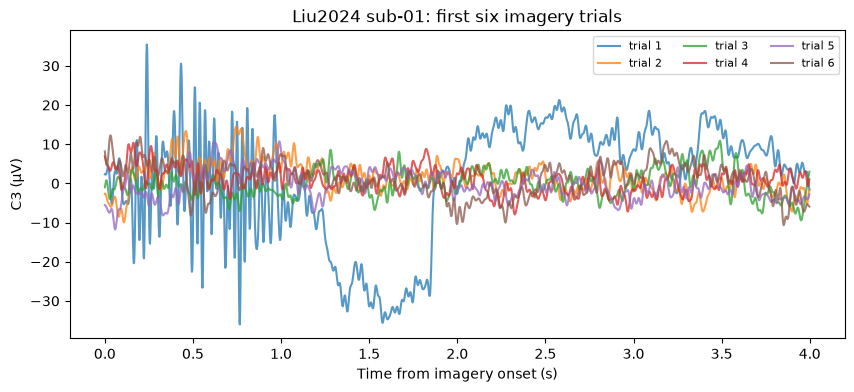

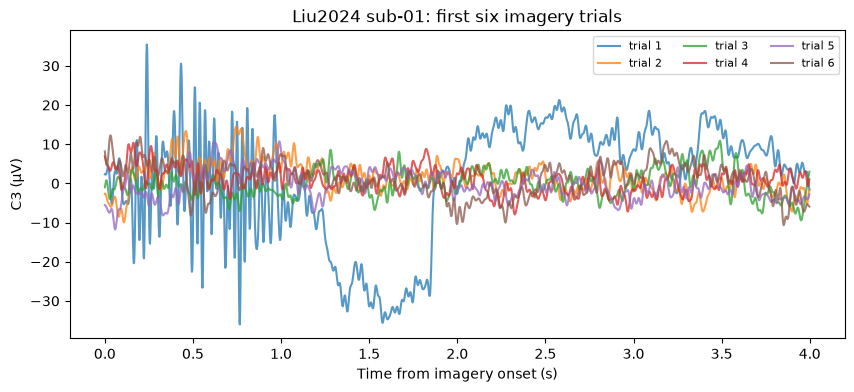

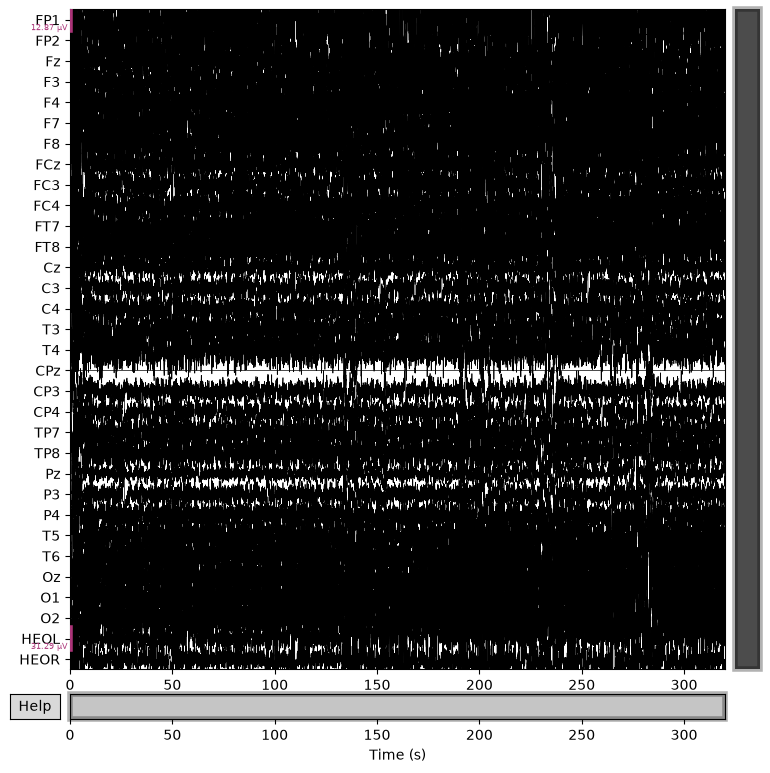

In [9]:
all_channels_figure = raw.plot(
    start=0,
    duration=raw.n_times / raw.info["sfreq"],
    n_channels=len(raw.ch_names),
    picks=raw.ch_names,
    scalings="auto",
    title=f"Liu2024 sub-{SUBJECT}: complete raw recording ({len(raw.ch_names)} channels)",
    show=True,
)

## Make 4-second motor-imagery epochs
The sidecar defines event times in milliseconds. Marker value 2 starts imagery; trial types 1 and 2 are left and right hand.

In [10]:
imagery = events_table.loc[events_table['value'] == 2].copy()
samples = raw.time_as_index(imagery['onset'].to_numpy() / 1000.0)
events = pd.DataFrame({'sample': samples, 'previous': 0,
                       'event_id': imagery['trial_type'].astype(int)}).to_numpy(dtype=int)
epochs = mne.Epochs(raw, events, event_id={'left_hand': 1, 'right_hand': 2},
                    tmin=0, tmax=4 - 1 / raw.info['sfreq'], baseline=None,
                    picks='eeg', preload=True, verbose='error')
print('Shape (trials, channels, samples):', epochs.get_data().shape)
epochs

Shape (trials, channels, samples): (40, 30, 2000)


<Epochs | 40 events (all good), 0 – 3.998 s (baseline off), ~18.3 MiB, data loaded,
 'left_hand': 20
 'right_hand': 20>

In [11]:
channel = 'C3'
signals = epochs.get_data(picks=channel)[:6, 0] * 1e6
fig, ax = plt.subplots(figsize=(10, 4))
for number, signal in enumerate(signals, 1):
    ax.plot(epochs.times, signal, alpha=.75, label=f'trial {number}')
ax.set(xlabel='Time from imagery onset (s)', ylabel=f'{channel} (µV)',
       title=f'Liu2024 sub-{SUBJECT}: first six imagery trials')
ax.legend(ncol=3, fontsize=8);